In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')


In [2]:
ds = pd.read_csv('data/stud.csv')

In [3]:
ds.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
ds.shape

(1000, 8)

gender : Sex of student(Male/Female)

race_ethnicity : ethnicity of student(Group A,B,C,D,E)

parental_level_of_education : parents's final education (Bachelor's degree, some college, master's degree, associate's degree, high school)

lunch : having lunch before test (standard or fee/reduced)

test_preparation_course : completed or not complete before test

math score

reading score

writing score




In [5]:
# Check Missing value
ds.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [6]:
# Check duplicate value
ds.duplicated().sum()

np.int64(0)

In [7]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
ds.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
ds.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [10]:
print("Categories in gender variables: ",end=" ")
print(ds['gender'].unique())

print("Categories in race_ethnicity variables: ",end=" ")
print(ds['race_ethnicity'].unique())

print("Categories in parental_level_of_education variables: ",end=" ")
print(ds['parental_level_of_education'].unique())

print("Categories in lunch variables: ",end=" ")
print(ds['lunch'].unique())

print("Categories in test preparation course variables: ",end=" ")
print(ds['test_preparation_course'].unique())


Categories in gender variables:  ['female' 'male']
Categories in race_ethnicity variables:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental_level_of_education variables:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch variables:  ['standard' 'free/reduced']
Categories in test preparation course variables:  ['none' 'completed']


In [13]:
#define numerical and categorical column
numerical_features = [feature for feature in ds.columns if ds[feature].dtype != 'O']
categorical_features = [feature for feature in ds.columns if ds[feature].dtype == 'O']

In [14]:
print("We have {} numerical features : {}".format(len(numerical_features), numerical_features))
print("\nWe have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 categorical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [15]:
#Adding columns for "Total score and Average"
ds['total_score'] = ds['math_score'] + ds['reading_score'] + ds['writing_score']
ds['average_score'] = ds['total_score']/3
ds.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [17]:
reading_full = ds[ds['reading_score'] == 100]['average_score'].count()
writing_full = ds[ds['writing_score'] == 100]['average_score'].count()
math_full = ds[ds['math_score'] == 100]['average_score'].count()

print(f'Number of student with full marks in Reading: {reading_full}')
print(f'Number of student with full marks in Writing: {writing_full}')
print(f'Number of student with full marks in Math: {math_full}')

Number of student with full marks in Reading: 17
Number of student with full marks in Writing: 14
Number of student with full marks in Math: 7


In [18]:
reading_less_20 = ds[ds['reading_score'] <= 20]['average_score'].count()
writing_less_20 = ds[ds['writing_score'] <= 20]['average_score'].count()
math_less_20 = ds[ds['math_score'] <= 20]['average_score'].count()

print(f'Number of student with less than 20 marks in reading: {reading_less_20}')
print(f'Number of student with less than 20 marks in writing: {writing_less_20}')
print(f'Number of student with less than 20 marks in Maths: {math_less_20}')

Number of student with less than 20 marks in reading: 1
Number of student with less than 20 marks in writing: 3
Number of student with less than 20 marks in Maths: 4


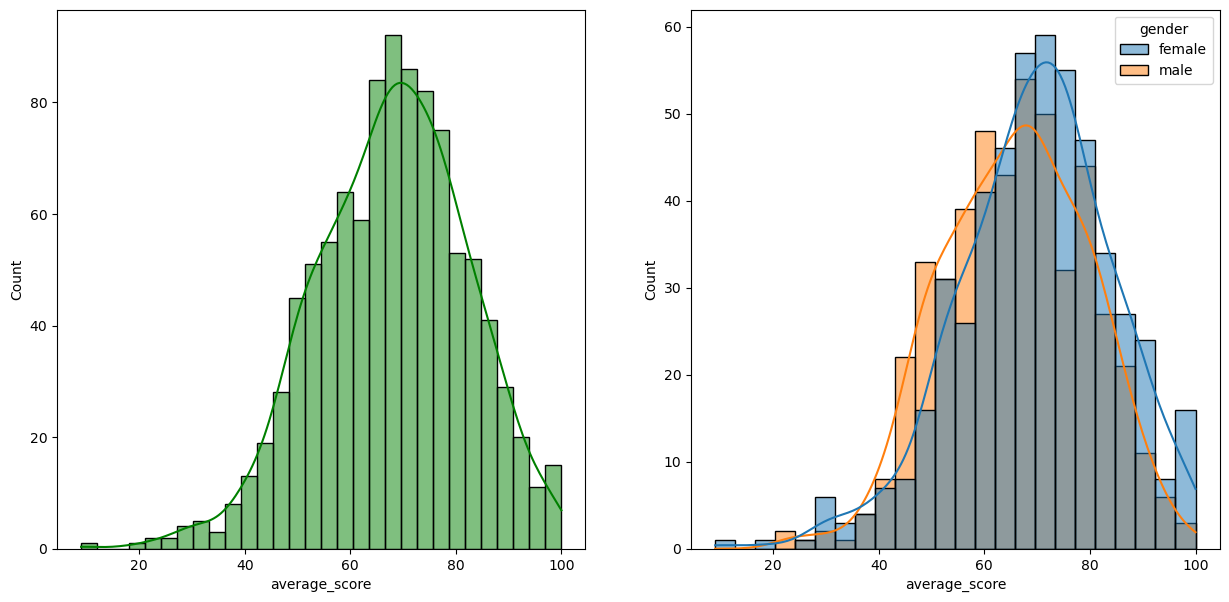

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=ds, x="average_score", bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(data=ds, x="average_score", kde=True, hue="gender", ax=axs[1])

plt.show()

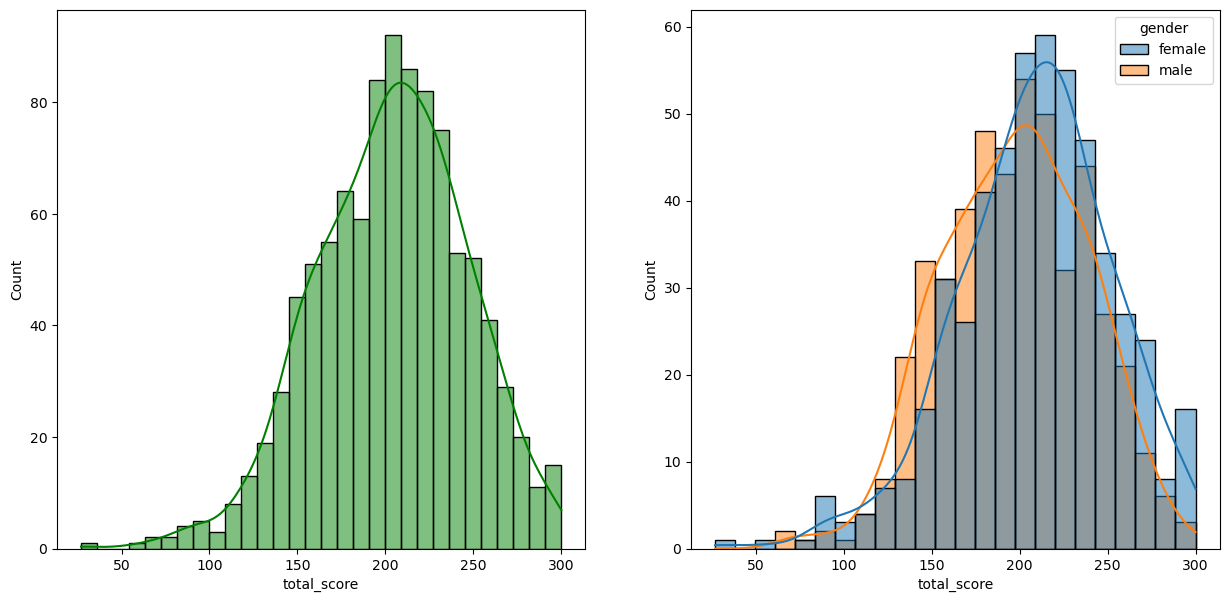

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

sns.histplot(data=ds, x="total_score", bins=30, kde=True, color='g', ax=axs[0])

sns.histplot(data=ds, x="total_score", kde=True, hue="gender", ax=axs[1])

plt.show()

Insights : Female student tend to perform well then male student

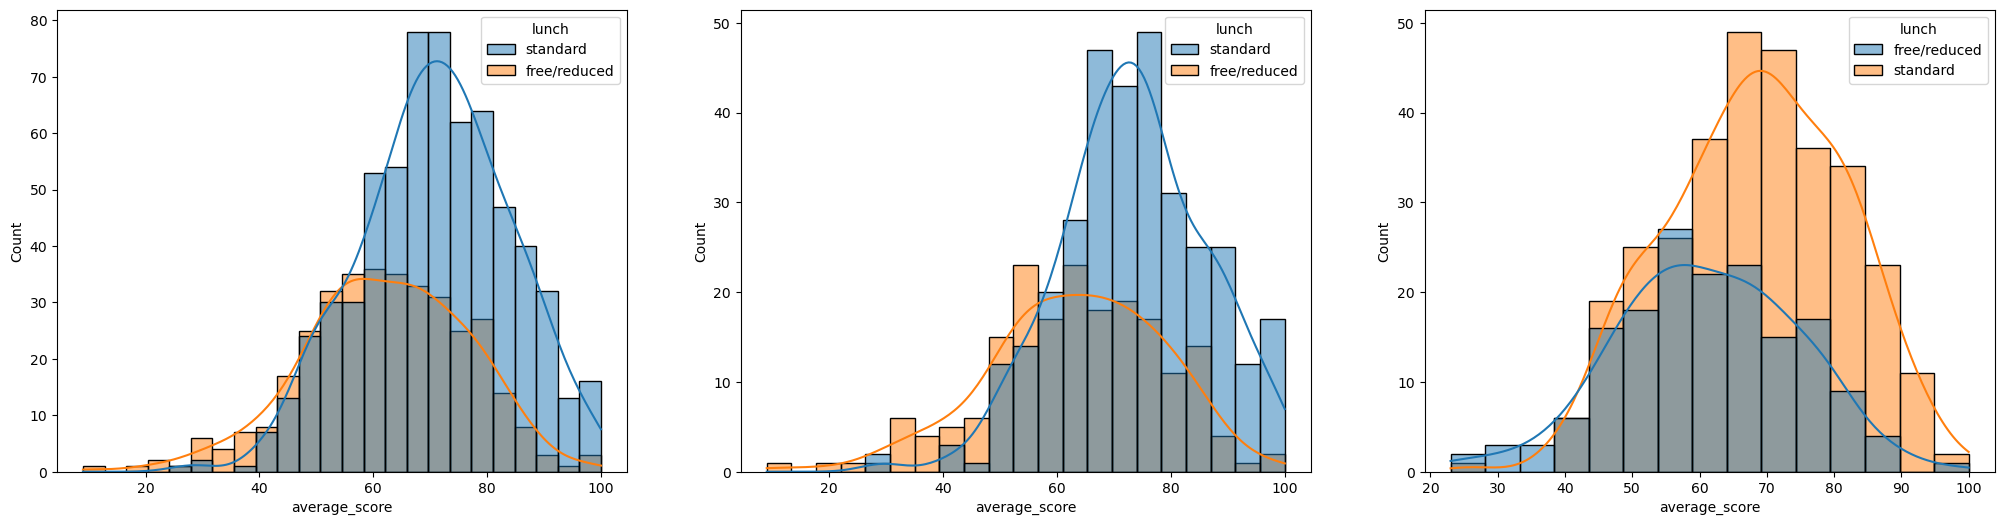

In [31]:
fig, axs = plt.subplots(1, 3, figsize=(25,6))

sns.histplot(data=ds, x='average_score', kde=True, hue='lunch', ax=axs[0])
sns.histplot(data=ds[ds.gender=='female'], x='average_score', kde=True, hue='lunch', ax=axs[1])
sns.histplot(data=ds[ds.gender=='male'], x='average_score', kde=True, hue='lunch', ax=axs[2])

plt.show()

Insights : standard lunch helps perform well in exams and standad lunch helps performs well in exam be it a male or a female